# 3D Surface Interpolation Visualization

## Overview

Given a coarse 2D grid of function values $f_{ij} = f(x_i, y_j)$, **2D interpolation** constructs a smooth or piecewise-smooth surface $\hat{f} : [0,1]^2 \to \mathbb{R}$ that passes through (or near) the given values. The choice of interpolation method has a dramatic effect on the visual appearance and the artifacts introduced.

## Interpolation Methods

### Nearest Neighbor
Assigns the value of the nearest grid point:
$$\hat{f}(x) = f_{i^*, j^*}, \quad (i^*, j^*) = \arg\min_{i,j} \|(x,y) - (x_i, y_j)\|$$
Produces a **piecewise constant** surface — staircase artifacts at grid boundaries.

### Bilinear Interpolation
Linearly interpolates within each grid cell:
$$\hat{f}(x,y) = (1-s)(1-t)f_{i,j} + s(1-t)f_{i+1,j} + (1-s)t f_{i,j+1} + st f_{i+1,j+1}$$
where $s = (x-x_i)/(x_{i+1}-x_i)$, $t = (y-y_j)/(y_{j+1}-y_j)$. Produces a **$C^0$ but not $C^1$** surface.

### Bicubic Interpolation
Uses a $4 \times 4$ neighborhood of grid points and cubic Hermite basis functions:
$$\hat{f}(x,y) = \sum_{m=0}^3 \sum_{n=0}^3 a_{mn} s^m t^n$$
Produces a **$C^1$** surface (matching function values and gradients at grid nodes).

### Spline Interpolation
Globally minimizes the bending energy $\int |\nabla^2 f|^2$ subject to interpolation constraints. Produces a **$C^2$** surface, the smoothest possible interpolant.

### Environment setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator, RectBivariateSpline
from mpl_toolkits.mplot3d import Axes3D
from ipywidgets import interact, Dropdown, IntSlider

### Coarse grid and function

We start from a $5 \times 5$ coarse grid of random values, mixed with a structured component to make the surface interesting.

In [2]:
rng = np.random.default_rng(12)

n_coarse = 5
x_c = np.linspace(0, 1, n_coarse)
y_c = np.linspace(0, 1, n_coarse)

# Structured + random coarse values
Yc, Xc = np.meshgrid(y_c, x_c)
F0 = rng.random((n_coarse, n_coarse)) + Xc  # trend + noise
F1 = rng.random((n_coarse, n_coarse)) + Yc.T
F0 = (F0 - F0.min()) / (F0.max() - F0.min())
F1 = (F1 - F1.min()) / (F1.max() - F1.min())

# Fine grid for evaluation
n_fine = 60
x_f = np.linspace(0, 1, n_fine)
y_f = np.linspace(0, 1, n_fine)
Yf, Xf = np.meshgrid(y_f, x_f)

print(f'Coarse grid: {n_coarse}×{n_coarse}, fine grid: {n_fine}×{n_fine}')

Coarse grid: 5×5, fine grid: 60×60


### Comparing interpolation methods

We use `scipy.interpolate.RegularGridInterpolator` for nearest, linear, and cubic methods, and `RectBivariateSpline` for the smoothing spline.

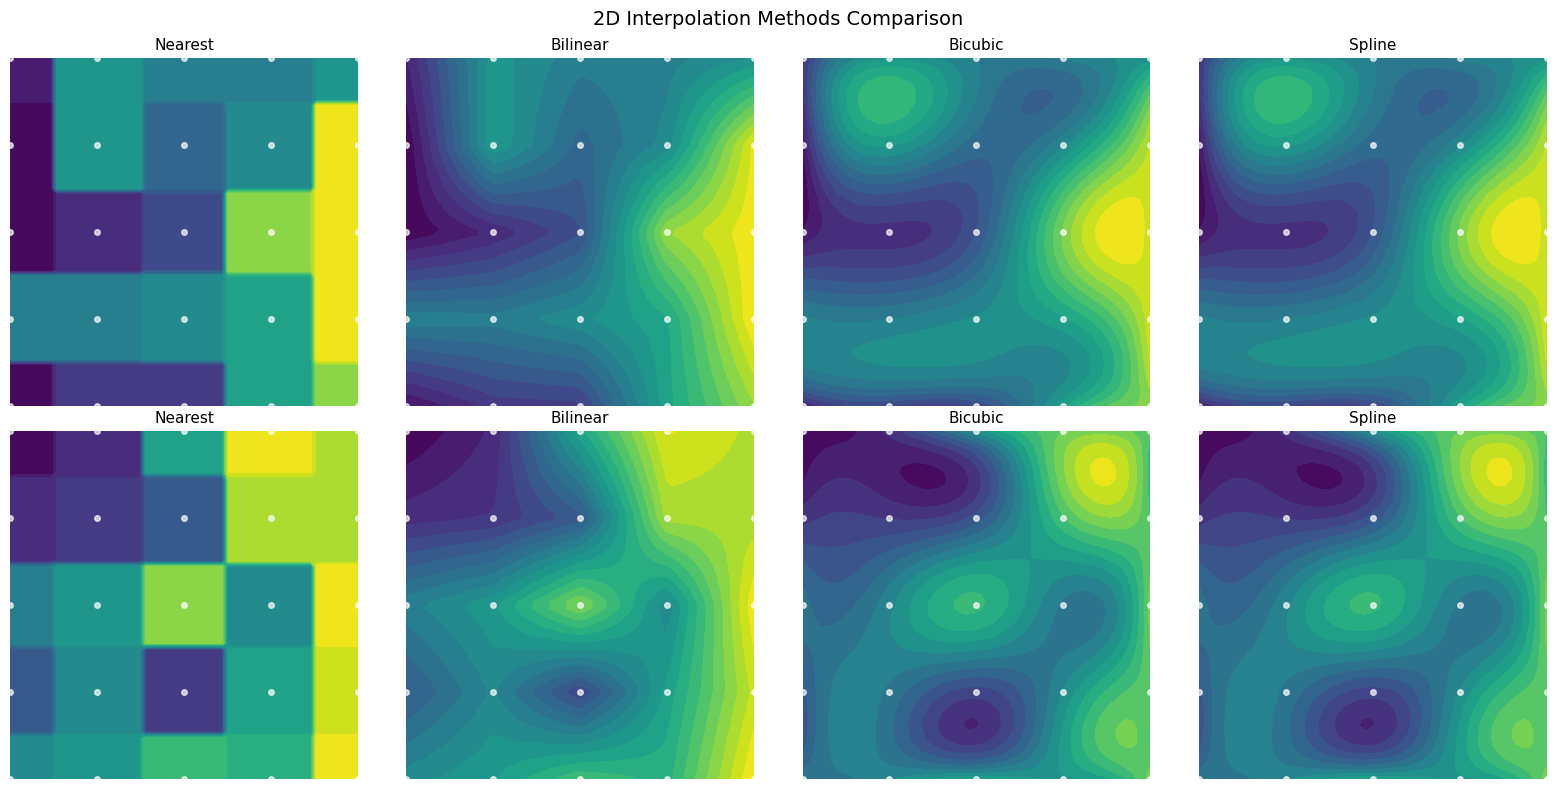

In [3]:
def interpolate_grid(x_c, y_c, F, x_f, y_f, method='linear'):
    pts_fine = np.column_stack([Xf.ravel(), Yf.ravel()])
    if method in ('nearest', 'linear', 'slinear', 'cubic', 'quintic'):
        interp = RegularGridInterpolator((x_c, y_c), F, method=method,
                                          bounds_error=False, fill_value=None)
        return interp(pts_fine).reshape(len(x_f), len(y_f))
    elif method == 'spline':
        spl = RectBivariateSpline(x_c, y_c, F, kx=3, ky=3)
        return spl(x_f, y_f)

methods = ['nearest', 'linear', 'cubic', 'spline']
method_labels = ['Nearest', 'Bilinear', 'Bicubic', 'Spline']

# Compute interpolations for both F0 and F1
results = {}
for F_name, F in [('F0', F0), ('F1', F1)]:
    results[F_name] = {m: interpolate_grid(x_c, y_c, F, x_f, y_f, m) for m in methods}

# Plot as 2D images
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for row, F_name in enumerate(['F0', 'F1']):
    for col, (m, label) in enumerate(zip(methods, method_labels)):
        ax = axes[row, col]
        Z = results[F_name][m]
        ax.contourf(Xf, Yf, Z, levels=20, cmap='viridis')
        F_c = F0 if F_name == 'F0' else F1
        ax.plot(Xc.ravel(), Yc.ravel(), 'w.', ms=8, alpha=0.7)
        ax.set_title(label, fontsize=11); ax.set_aspect('equal')
        ax.axis('off')
    axes[row, 0].set_ylabel(f'Surface {F_name}', fontsize=11)

plt.suptitle('2D Interpolation Methods Comparison', fontsize=14)
plt.tight_layout(); plt.savefig('interp_compare.png', dpi=100, bbox_inches='tight'); plt.show()

### 3D surface rendering

The 3D view makes the smoothness differences between methods visually obvious. Nearest-neighbor shows sharp steps; cubic and spline produce smooth undulating surfaces.

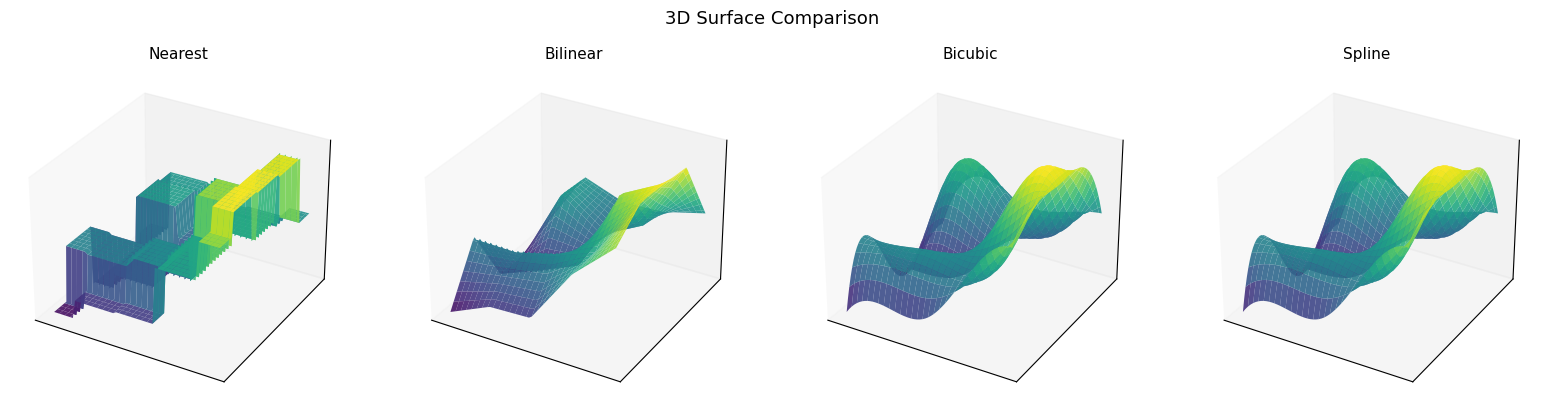

In [4]:
fig = plt.figure(figsize=(16, 4))
for col, (m, label) in enumerate(zip(methods, method_labels)):
    ax = fig.add_subplot(1, 4, col+1, projection='3d')
    Z = results['F0'][m]
    ax.plot_surface(Xf, Yf, Z, cmap='viridis', alpha=0.9,
                    linewidth=0, antialiased=True)
    ax.set_title(label, fontsize=11)
    ax.set_zlim(0, 1)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])

plt.suptitle('3D Surface Comparison', fontsize=13, y=1.02)
plt.tight_layout(); plt.savefig('interp_3d.png', dpi=100, bbox_inches='tight'); plt.show()

### Morphing between two surfaces

Interpolation in the space of functions: we linearly combine two coarse function values $F_0$ and $F_1$ and re-interpolate, showing a smooth morph between the two surfaces.

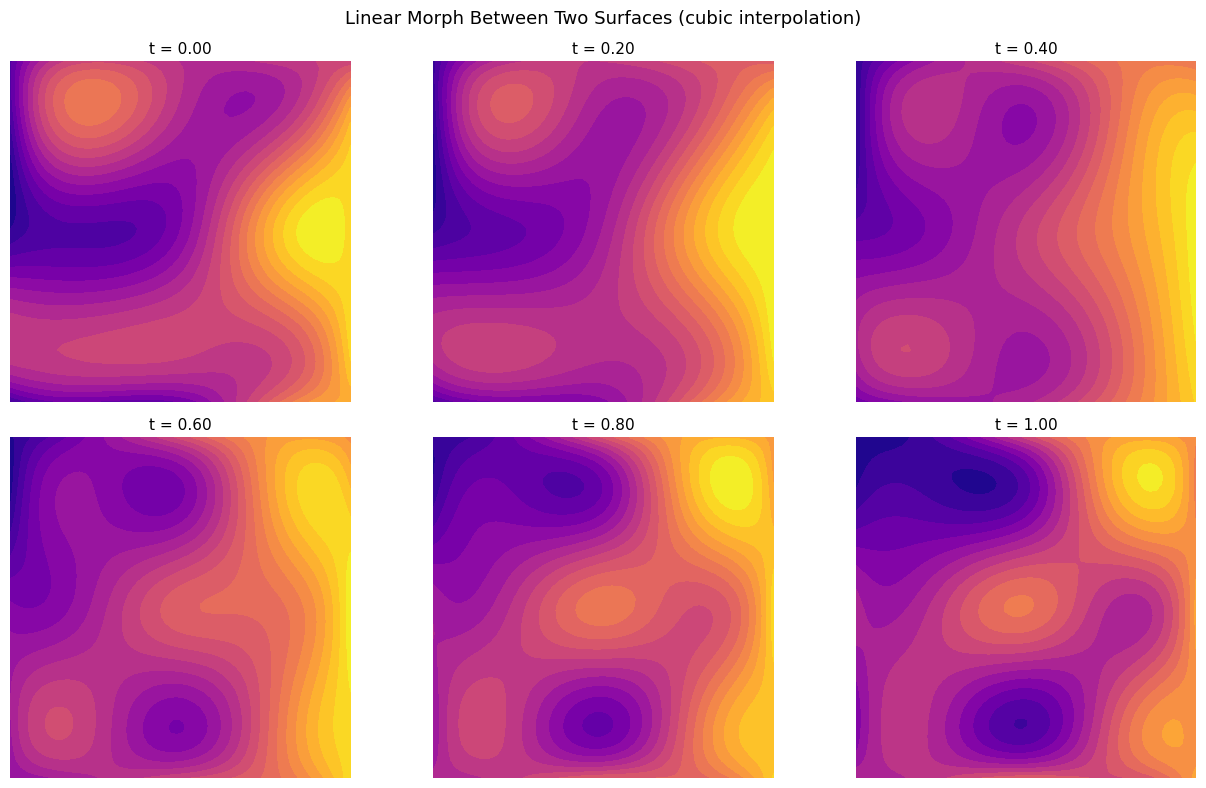

In [5]:
t_vals = np.linspace(0, 1, 6)
method_morph = 'cubic'

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for ax, t_v in zip(axes.ravel(), t_vals):
    F_mix = (1 - t_v) * F0 + t_v * F1
    Z = interpolate_grid(x_c, y_c, F_mix, x_f, y_f, method_morph)
    ax.contourf(Xf, Yf, Z, levels=20, cmap='plasma')
    ax.set_title(f't = {t_v:.2f}', fontsize=11)
    ax.set_aspect('equal'); ax.axis('off')

plt.suptitle(f'Linear Morph Between Two Surfaces ({method_morph} interpolation)', fontsize=13)
plt.tight_layout(); plt.savefig('interp_morph.png', dpi=100, bbox_inches='tight'); plt.show()

### Interactive: method and coarseness

In [ ]:
def show_interp(method='cubic', n_grid=5, seed=42):
    rng_w = np.random.default_rng(seed)
    x_cw = np.linspace(0, 1, n_grid)
    y_cw = np.linspace(0, 1, n_grid)
    Ycw, Xcw = np.meshgrid(y_cw, x_cw)
    Fw = rng_w.random((n_grid, n_grid)) + Xcw
    Fw = (Fw - Fw.min()) / (Fw.max() - Fw.min())

    try:
        Zw = interpolate_grid(x_cw, y_cw, Fw, x_f, y_f, method)
    except Exception:
        return

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(Fw.T, cmap='viridis', origin='lower', aspect='equal')
    axes[0].set_title(f'Coarse grid ({n_grid}×{n_grid})')
    axes[1].contourf(Xf, Yf, Zw, levels=20, cmap='viridis')
    axes[1].plot(Xcw.ravel(), Ycw.ravel(), 'w.', ms=8)
    axes[1].set_title(f'{method} interpolation')
    axes[1].set_aspect('equal')
    plt.tight_layout(); plt.show()

interact(show_interp,
         method=Dropdown(options=['nearest','linear','cubic','spline'], value='cubic'),
         n_grid=IntSlider(min=3, max=12, step=1, value=5),
         seed=IntSlider(min=0, max=20, step=1, value=42));

### Snippet

In [6]:
STATIC_SNAPSHOT = True
if STATIC_SNAPSHOT:
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as _plt

    fig, axes = _plt.subplots(2, 4, figsize=(14, 7))
    cmaps_s = ['viridis', 'plasma', 'inferno', 'magma']
    for row, F_name in enumerate(['F0', 'F1']):
        for col, (m, label, cmap_s) in enumerate(zip(methods, method_labels, cmaps_s)):
            ax = axes[row, col]
            Z = results[F_name][m]
            ax.contourf(Xf, Yf, Z, levels=20, cmap=cmap_s)
            ax.set_title(label if row==0 else '', fontsize=10)
            ax.set_aspect('equal'); ax.axis('off')
    fig.tight_layout()
    fig.savefig('snippet.png', dpi=150, bbox_inches='tight')

## Takeaways

- **Nearest-neighbor** interpolation is the simplest but produces staircase artifacts.
- **Bilinear** interpolation is $C^0$ — continuous but with kinks at grid boundaries.
- **Bicubic** interpolation is $C^1$ — continuous gradients, much smoother visual appearance.
- **Spline** interpolation is $C^2$ — minimizes bending energy, giving the globally smoothest surface for the given grid values.

## Bibliography

- C. de Boor, *A Practical Guide to Splines*, Springer, 1978.
- W. H. Press et al., *Numerical Recipes*, Cambridge UP, 2007.
- R. Keys, *Cubic convolution interpolation for digital image processing*, IEEE TASSP 29(6), 1981.